In [90]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve, precision_score, recall_score, f1_score, RocCurveDisplay

In [59]:
df = pd.read_csv('/content/diabetic_data.csv')
df

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101761,443847548,100162476,AfricanAmerican,Male,[70-80),?,1,3,7,3,...,No,Down,No,No,No,No,No,Ch,Yes,>30
101762,443847782,74694222,AfricanAmerican,Female,[80-90),?,1,4,5,5,...,No,Steady,No,No,No,No,No,No,Yes,NO
101763,443854148,41088789,Caucasian,Male,[70-80),?,1,1,7,1,...,No,Down,No,No,No,No,No,Ch,Yes,NO
101764,443857166,31693671,Caucasian,Female,[80-90),?,2,3,7,10,...,No,Up,No,No,No,No,No,Ch,Yes,NO


In [60]:
df.head(5)

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [61]:
df.columns

Index(['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight',
       'admission_type_id', 'discharge_disposition_id', 'admission_source_id',
       'time_in_hospital', 'payer_code', 'medical_specialty',
       'num_lab_procedures', 'num_procedures', 'num_medications',
       'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1',
       'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult',
       'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
       'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'examide', 'citoglipton', 'insulin',
       'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted'],
      dtype='object')

In [62]:
df.isnull().sum()

,0
encounter_id,0
patient_nbr,0
race,0
gender,0
age,0
weight,0
admission_type_id,0
discharge_disposition_id,0
admission_source_id,0
time_in_hospital,0


In [63]:
missing_values = df.isnull().sum()
missing_percentage = (missing_values / len(df)) * 100
print(missing_percentage)

encounter_id                 0.000000
patient_nbr                  0.000000
race                         0.000000
gender                       0.000000
age                          0.000000
weight                       0.000000
admission_type_id            0.000000
discharge_disposition_id     0.000000
admission_source_id          0.000000
time_in_hospital             0.000000
payer_code                   0.000000
medical_specialty            0.000000
num_lab_procedures           0.000000
num_procedures               0.000000
num_medications              0.000000
number_outpatient            0.000000
number_emergency             0.000000
number_inpatient             0.000000
diag_1                       0.000000
diag_2                       0.000000
diag_3                       0.000000
number_diagnoses             0.000000
max_glu_serum               94.746772
A1Cresult                   83.277322
metformin                    0.000000
repaglinide                  0.000000
nateglinide 

In [64]:
df.describe()

,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,1.017660e+05,1.017660e+05,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,1.652016e+08,5.433040e+07,2.024006,3.715642,5.754437,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607
std,1.026403e+08,3.869636e+07,1.445403,5.280166,4.064081,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600
min,1.252200e+04,1.350000e+02,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,8.496119e+07,2.341322e+07,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,1.523890e+08,4.550514e+07,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,2.302709e+08,8.754595e+07,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,4.438672e+08,1.895026e+08,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


In [65]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

In [66]:
[features for features in df.columns if df[features].isnull().sum()>0]

['max_glu_serum', 'A1Cresult']

In [67]:
# Replace missing values represented by '?'
df = df.replace("?", pd.NA)
df.head(5)

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),<NA>,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),<NA>,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),<NA>,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),<NA>,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),<NA>,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [68]:
df.sample(5)

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
99743,417228428,69281748,Caucasian,Male,[70-80),<NA>,1,1,7,3,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
8491,38337204,18132786,Caucasian,Female,[50-60),<NA>,2,1,1,9,...,No,Down,No,No,No,No,No,Ch,Yes,NO
97678,391461848,100047780,Caucasian,Male,[70-80),<NA>,1,1,7,3,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
22394,77260584,3567897,Hispanic,Male,[50-60),<NA>,1,22,7,5,...,No,No,No,No,No,No,No,Ch,Yes,<30
6245,31274964,23379867,Caucasian,Male,[70-80),<NA>,1,1,17,2,...,No,No,No,No,No,No,No,Ch,Yes,>30


In [69]:
df['readmitted'].value_counts()

,count
readmitted,
NO,54864
>30,35545
<30,11357


In [70]:
df["readmitted_30"] = df["readmitted"].apply(
    lambda x: 1 if x == "<30" else 0
)

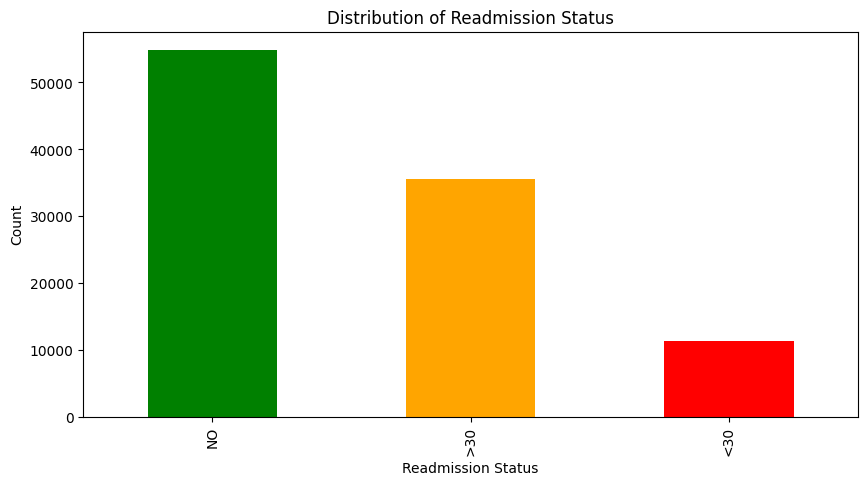

In [71]:
plt.figure(figsize=(10, 5))
df['readmitted'].value_counts().plot(kind='bar', color=['green', 'orange', 'red'])
plt.xlabel('Readmission Status')
plt.ylabel('Count')
plt.title('Distribution of Readmission Status')
#plt.xticks(rotation=0)
#plt.tight_layout()
plt.show()

In [72]:
df["readmitted_30"].value_counts()

,count
readmitted_30,
0,90409
1,11357


In [73]:
columns_to_remove = ['encounter_id', 'patient_nbr', 'weight', 'payer_code', 'medical_specialty']

df_cleaned = df.drop(columns=columns_to_remove, errors='ignore')

print(f"Columns removed: {columns_to_remove}")
print(f"New shape: {df_cleaned.shape}")

Columns removed: ['encounter_id', 'patient_nbr', 'weight', 'payer_code', 'medical_specialty']
New shape: (101766, 46)


In [74]:
for col in df_cleaned.columns:
    if df_cleaned[col].isnull().sum() > 0:
        if df_cleaned[col].dtype == 'object':
            df_cleaned[col].fillna(df_cleaned[col].mode()[0], inplace=True)
        else:
            df_cleaned[col].fillna(df_cleaned[col].median(), inplace=True)

print("Missing values handled successfully")
print(f"Remaining missing values: {df_cleaned.isnull().sum().sum()}")

/tmp/ipykernel_2103/71335400.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_cleaned[col].fillna(df_cleaned[col].mode()[0], inplace=True)


Missing values handled successfully
Remaining missing values: 0


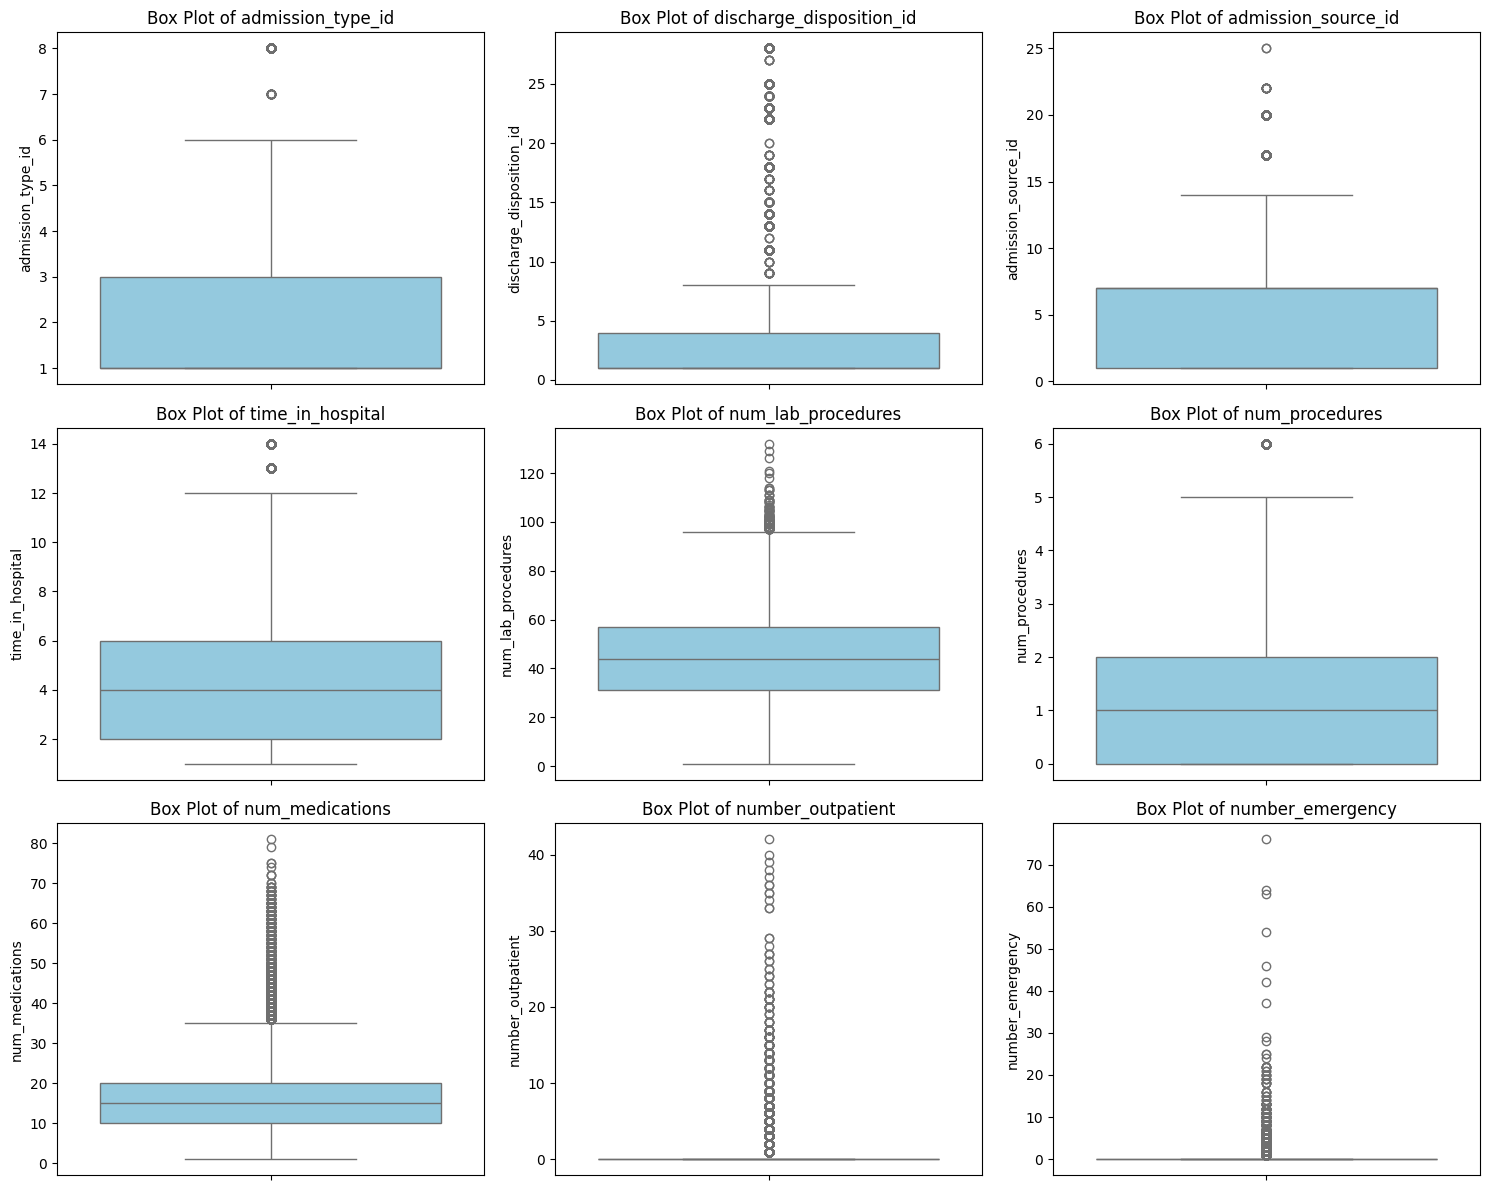

In [75]:
# Select columns
numerical_cols = [c for c in df_cleaned.select_dtypes(include=[np.number]).columns if c != 'readmitted_30'][:9]

# Set up grid
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.ravel()

# Plot boxplots
for idx, col in enumerate(numerical_cols):
    sns.boxplot(data=df_cleaned, y=col, ax=axes[idx], color='skyblue')
    axes[idx].set_title(f'Box Plot of {col}')
    axes[idx].set_ylabel(col)

plt.tight_layout()
plt.show()


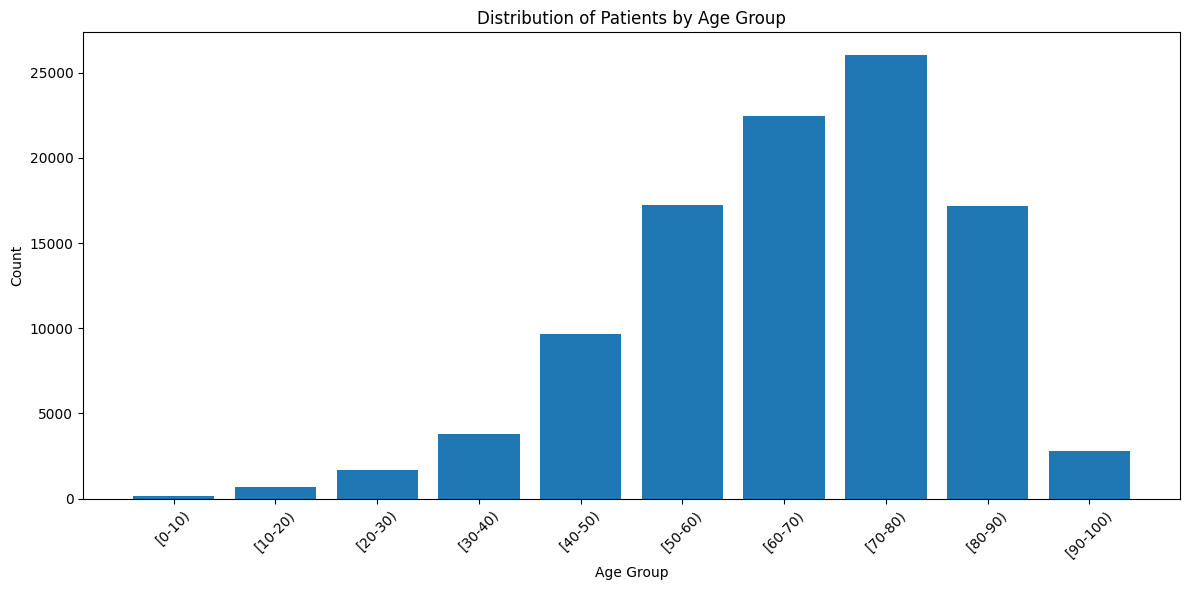

In [76]:
age_order = ['[0-10)', '[10-20)', '[20-30)', '[30-40)', '[40-50)',
             '[50-60)', '[60-70)', '[70-80)', '[80-90)', '[90-100)']

plt.figure(figsize=(12, 6))
age_counts = df_cleaned['age'].value_counts().reindex(age_order)
plt.bar(range(len(age_counts)), age_counts.values)
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.title('Distribution of Patients by Age Group')
plt.xticks(range(len(age_counts)), age_counts.index, rotation=45)
plt.tight_layout()
plt.show()

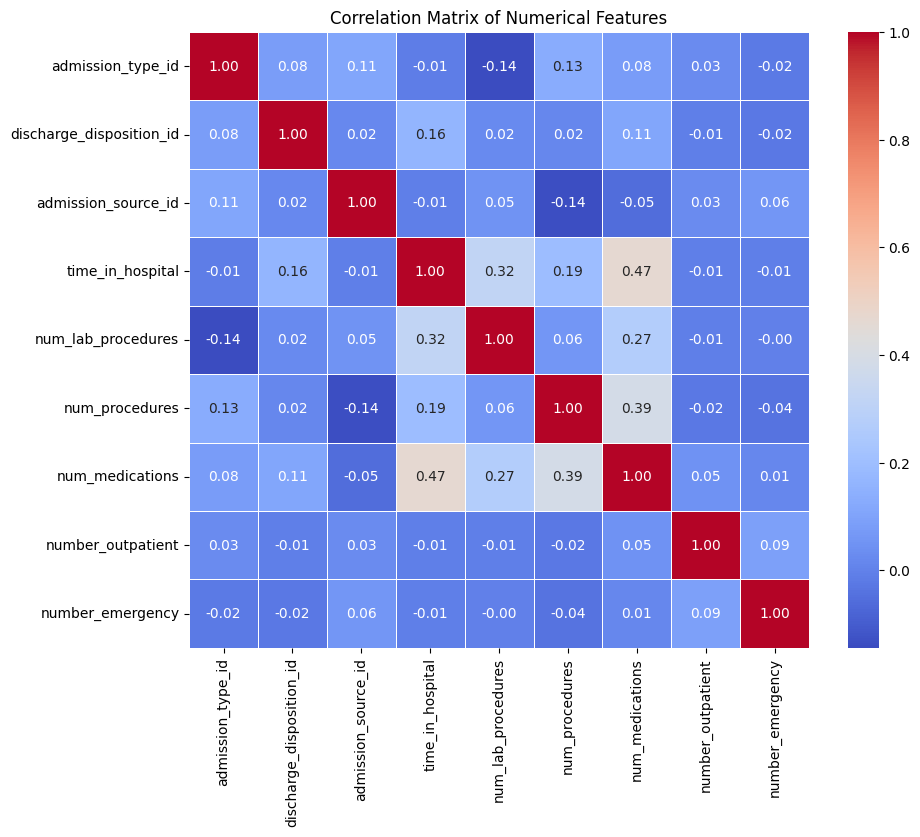

In [77]:
corr = df_cleaned[numerical_cols].corr()

# Plot the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Correlation Matrix of Numerical Features')
plt.show()

<Figure size 1000x600 with 0 Axes>

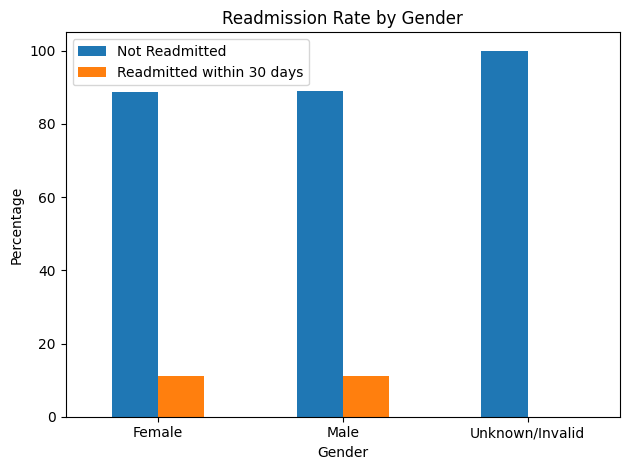

In [81]:
gender_readmission = pd.crosstab(df_cleaned['gender'], df_cleaned['readmitted_30'], normalize='index') * 100

plt.figure(figsize=(10, 6))
gender_readmission.plot(kind='bar', stacked=False)
plt.xlabel('Gender')
plt.ylabel('Percentage')
plt.title('Readmission Rate by Gender')
plt.legend(['Not Readmitted', 'Readmitted within 30 days'])
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [82]:
categorical_cols = df_cleaned.select_dtypes(include=['object']).columns.tolist()
categorical_cols = [col for col in categorical_cols if col not in ['readmitted', 'readmitted_binary']]

print(f"Categorical columns to encode: {categorical_cols}")

label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df_cleaned[col] = le.fit_transform(df_cleaned[col].astype(str))
    label_encoders[col] = le

print("Categorical encoding completed")

Categorical columns to encode: ['race', 'gender', 'age', 'diag_1', 'diag_2', 'diag_3', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed']
Categorical encoding completed


In [83]:
X = df_cleaned.drop(['readmitted', 'readmitted_30'], axis=1)
y = df_cleaned['readmitted_30']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nTarget distribution:")
print(y.value_counts())
print(f"\nClass balance:")
print(y.value_counts(normalize=True))

Features shape: (101766, 44)
Target shape: (101766,)

Target distribution:
readmitted_30
0    90409
1    11357
Name: count, dtype: int64

Class balance:
readmitted_30
0    0.888401
1    0.111599
Name: proportion, dtype: float64


In [84]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")
print(f"\nTraining target distribution:")
print(y_train.value_counts())
print(f"\nTest target distribution:")
print(y_test.value_counts())

Training set size: (81412, 44)
Test set size: (20354, 44)

Training target distribution:
readmitted_30
0    72340
1     9072
Name: count, dtype: int64

Test target distribution:
readmitted_30
0    18069
1     2285
Name: count, dtype: int64


In [85]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed")
print(f"Scaled training data shape: {X_train_scaled.shape}")
print(f"Scaled test data shape: {X_test_scaled.shape}")

Feature scaling completed
Scaled training data shape: (81412, 44)
Scaled test data shape: (20354, 44)


In [86]:
lr_model = LogisticRegression(penalty='l2', max_iter=1000)
lr_model.fit(X_train_scaled, y_train)

y_pred = lr_model.predict(X_test_scaled)
lr_accuracy = accuracy_score(y_test, y_pred)

print(f"Logistic Regression Accuracy: {lr_accuracy:.4f}")

Logistic Regression Accuracy: 0.8873


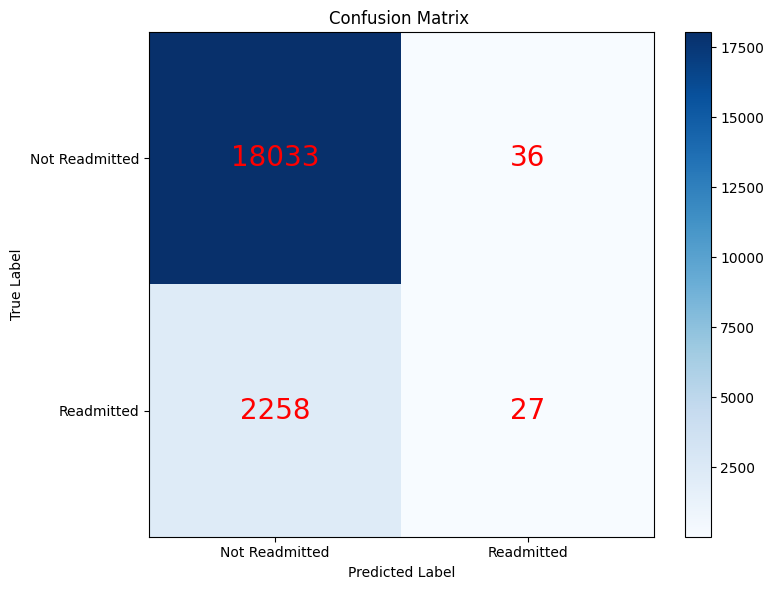

In [88]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
plt.imshow(cm, cmap='Blues', aspect='auto')
plt.colorbar()
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title(f'Confusion Matrix ')
plt.xticks([0, 1], ['Not Readmitted', 'Readmitted'])
plt.yticks([0, 1], ['Not Readmitted', 'Readmitted'])

for i in range(2):
    for j in range(2):
        plt.text(j, i, str(cm[i, j]), ha='center', va='center', color='red', fontsize=20)

plt.tight_layout()
plt.show()

In [92]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     18069
           1       0.43      0.01      0.02      2285

    accuracy                           0.89     20354
   macro avg       0.66      0.50      0.48     20354
weighted avg       0.84      0.89      0.84     20354



/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


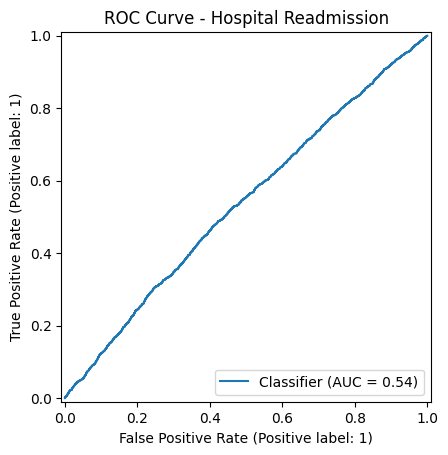

In [91]:
y_probability = lr_model.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_probability)
RocCurveDisplay.from_predictions(
    y_test,
    y_probability
)
plt.title("ROC Curve - Hospital Readmission")
plt.show()